### Фокин Никита 5130901/30201
## Упражнения по главе 1.

### Упражение 2.2

В ходе выполнения данного упражнения был создан класс пилообразного сигнала:

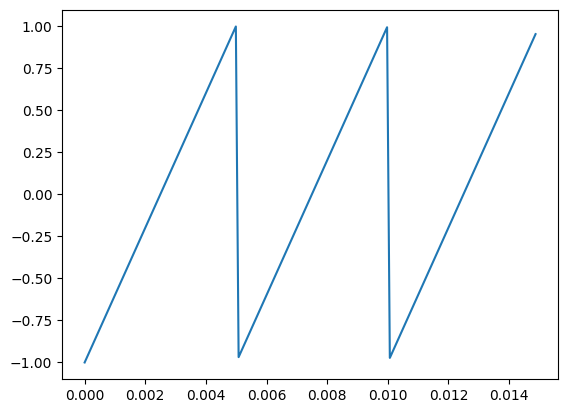

In [10]:
from thinkdsp import Sinusoid, normalize, unbias
from math import pi
import numpy as np

class SawtoothSignal (Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / (2*pi)
        frac,_= np.modf (cycles)
        ys = np.abs (frac + 1)
        ys = normalize (unbias (ys), self.amp)
        return ys

signal = SawtoothSignal(200)
signal.plot()

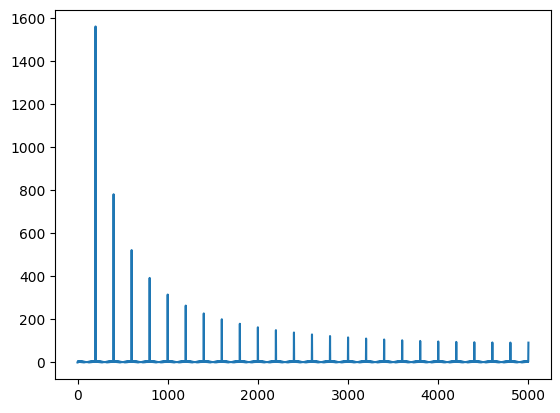

In [11]:
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()

 Спектр пилообразного сигнала содержит все гармоники (как четные, так и нечетные), амплитуды которых убывают обратно пропорционально номеру гармоники из-за скачка в форме сигнала. По скорости убывания гармоник ($`1/n`$) он аналогичен прямоугольному, но, в отличие от него, содержит полный набор частот, а не только нечетные. В свою очередь, треугольный сигнал, являясь непрерывным, имеет спектр только из нечетных гармоник, затухающих значительно быстрее. 

### Упражнение 2.3

В ходе выполнения данного упражнения был создан прямоугольный сигнал:

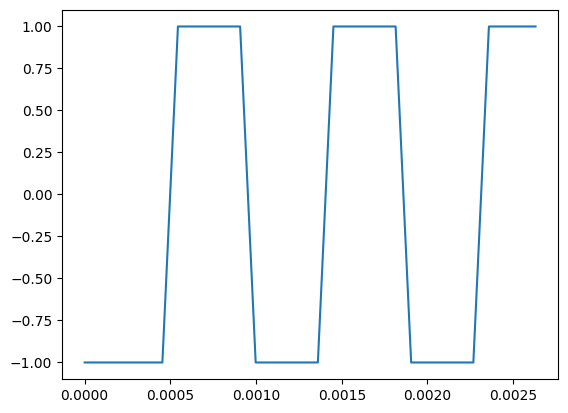

In [12]:
from thinkdsp import SquareSignal

signal = SquareSignal(1100)
signal.plot()

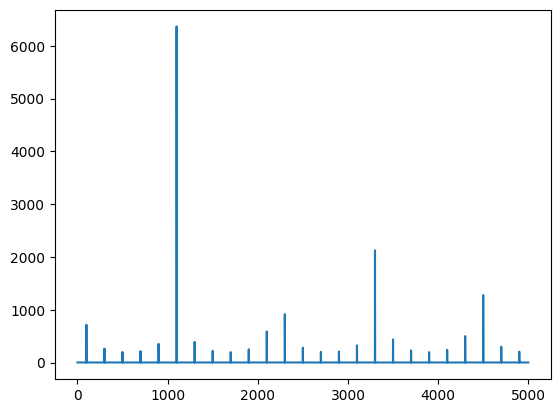

In [13]:
wave = signal.make_wave(duration=1, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()

In [14]:
wave.make_audio()

При прослушивании появляются заметные искажения и посторонние призвуки, так как отраженные гармоники попадают в полосу слышимых частот и взаимодействуют с основными.

### Упражнение 2.4

В ходе выполнения данного задания были выведены несколько первых значений spectrum.fs, которые начинаются с нуля. Первое значение hs является комплексным и близким к нулю:

In [15]:
spectrum.fs[:3]

array([0., 1., 2.])

In [16]:
spectrum.hs[0]

np.complex128(2+0j)

Создание треугольного сигнала:

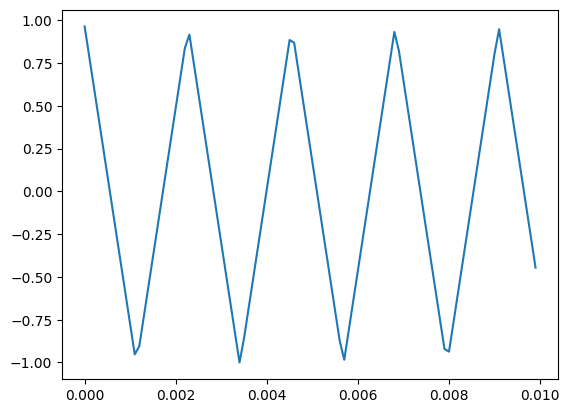

In [17]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(440)
wave = signal.make_wave(duration=0.01, framerate=10000)

wave.plot()

In [18]:
spectrum = wave.make_spectrum()
spectrum.hs[0]

np.complex128(3.375077994860476e-14+0j)

Такое малое значение амплитуды ожидаемо, поскольку треугольный сигнал симметричен относительно нуля и не содержит постоянного смещения. Полученная величина обусловлена погрешностями численных вычислений.

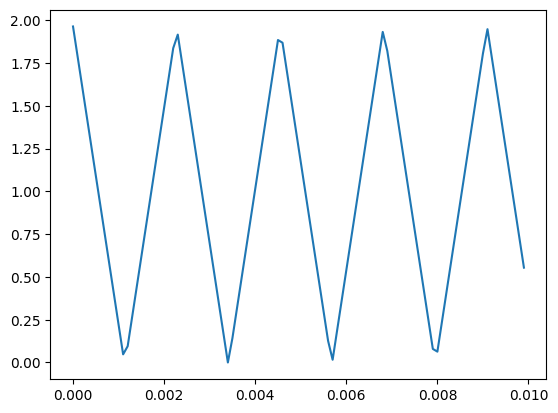

In [19]:
spectrum.hs[0] = 100
wave_2 = spectrum.make_wave()
wave_2.plot()

Поскольку spectrum.hs[0] соответствует нулевой частоте, то происходит смещение всей формы сигнала вверх на 100 единиц по оси амплитуд.

### Упражнение 2.5

Была создана функция изменения каждого элемента hs спектра:

In [20]:
def spec_change(spectrum):
    spectrum.hs[0] = 0
    for i in range(1, len(spectrum.hs)):
        spectrum.hs[i] /= spectrum.fs[i]


Проверка на треугольном сигнале:

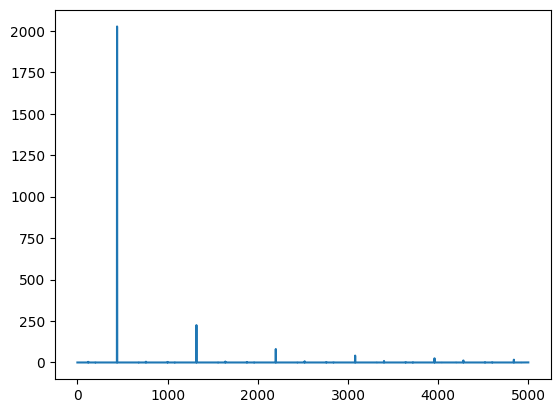

In [21]:
signal = TriangleSignal(440)
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()


In [22]:
wave.make_audio()

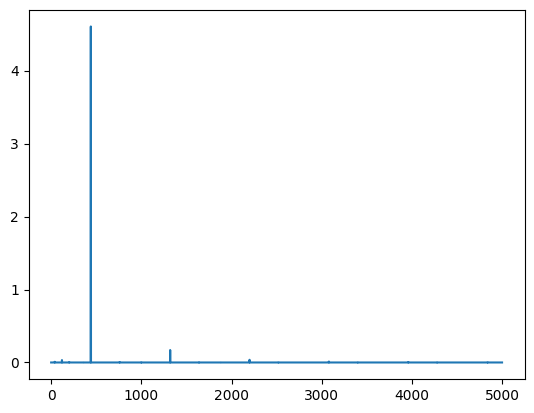

In [23]:
spec_change(spectrum)
spectrum.plot()

In [24]:
spectrum.make_wave().make_audio()

Проверка прямоугольного сигнала:

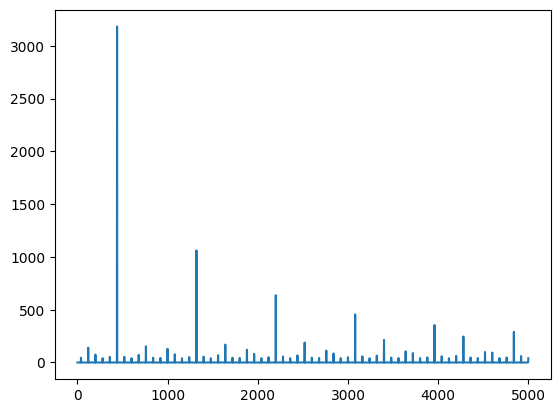

In [25]:
signal = SquareSignal(440)
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()

In [26]:
wave.make_audio()

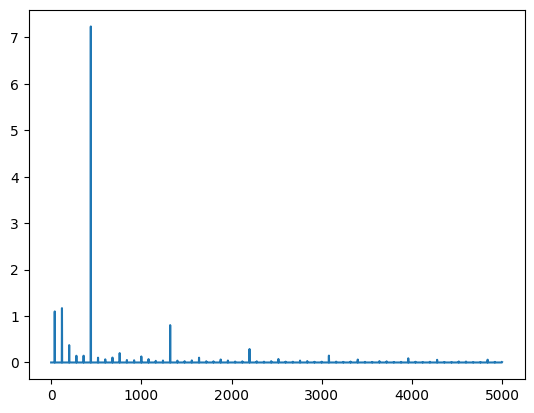

In [27]:
spec_change(spectrum)
spectrum.plot()

In [28]:
spectrum.make_wave().make_audio()

Проверка пилообразного сигнала:

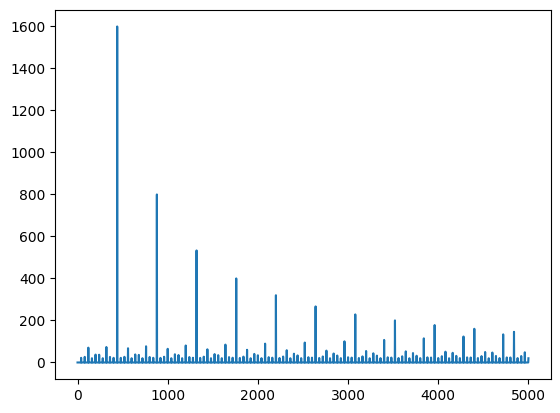

In [29]:
signal = SawtoothSignal(440)
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()

In [30]:
wave.make_audio()

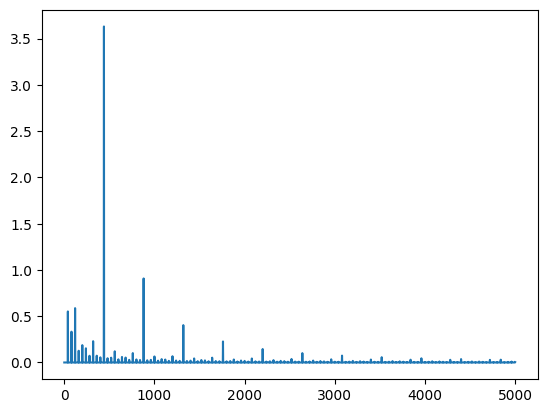

In [31]:
spec_change(spectrum)
spectrum.plot()

In [32]:
spectrum.make_wave().make_audio()

Из полученных спектров видно, что гармоники пилообразного и прямоугольного сигналов после применения функции уменьшаются пропорционально $`1/f^2`$, когда до этого они уменьшались пропорционально $`1/f`$. Гармоники треугольных сигналов теперь спадают пропорционально $`1/f^3`$. При этом высокие частоты срезаются сильнее, чем низкие, и на слух сигналы воспринимаются приглушенными, по сравнению с их изначальным видом.

### Упражнение 2.6

В ходе выполнения данного задания был получен искомый сигнал с использованием SawtoothSignal

In [33]:
signal = SawtoothSignal(500)
wave = signal.make_wave(duration=0.5, framerate=20000)
wave.make_audio()

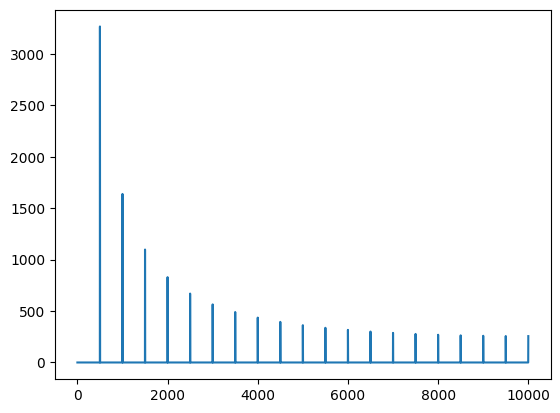

In [34]:
spectrum = wave.make_spectrum()
spectrum.plot()

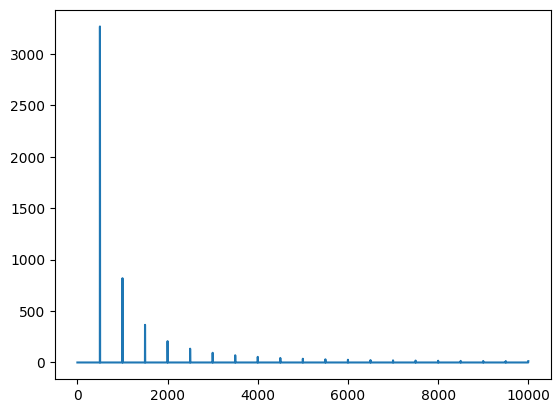

In [35]:
spec_change(spectrum)
spectrum.scale(500)
spectrum.plot()

In [36]:
spectrum.make_wave().make_audio()

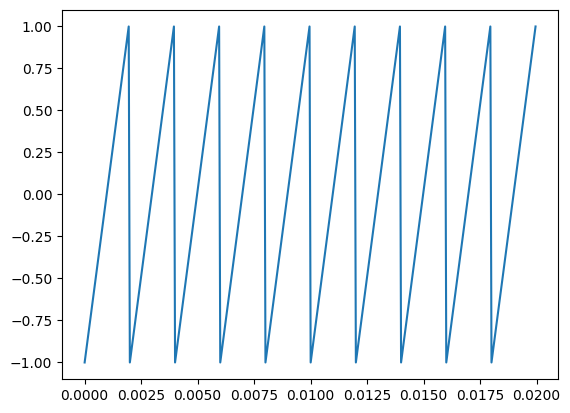

In [38]:
wave.segment(duration=0.02).plot()

Таким образом, получаем сигнал, состоящий из четных и нечетных гармоник, спадающих пропорционально $`1/f^2`$.